## Customer Personality Analysis

Dataset link: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

### Dataset Overview

Dataset Name - Customer Personality Analysis Dataset
Source - Kaggle

Dataset Purpose - This dataset contains customer demographic information, purchasing behavior, and campaign response details used for customer segmentation and marketing analytics.

Target Variable - Response
     - `1` = Customer accepted campaign  
     - `0` = Customer did not accept campaign  

---

### Important Columns Explanation**

**Customer Information**
| Column | Meaning |
|--------|---------|
| Year_Birth | Customer birth year |
| Education | Education qualification |
| Marital_Status | Marital status |
| Income | Annual household income |
| Kidhome | Number of kids in home |
| Teenhome | Number of teenagers in home |

**Purchase Spending Columns**
| Column | Meaning |
|--------|---------|
| MntWines | Money spent on wine |
| MntFruits | Money spent on fruits |
| MntMeatProducts | Money spent on meat |
| MntFishProducts | Money spent on fish |
| MntSweetProducts | Money spent on sweets |
| MntGoldProds | Money spent on gold products |

**Purchase Channel Columns**
| Column | Meaning |
|--------|---------|
| NumWebPurchases | Purchases made online |
| NumCatalogPurchases | Purchases via catalog |
| NumStorePurchases | Purchases made in store |
| NumWebVisitsMonth | Website visits per month |

**Campaign Columns**
| Column | Meaning |
|--------|---------|
| AcceptedCmp1–5 | Accepted previous campaigns |
| Response | Accepted latest campaign |

**Customer Activity Columns**
| Column | Meaning |
|--------|---------|
| Recency | Days since last purchase |
| Complain | Whether customer complained |

---
> *“The dataset combines demographic, behavioral, and campaign-related information, making it suitable for both clustering and predictive analytics.”*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. DATA LOADING & INITIAL INSPECTION

In [2]:
df = pd.read_csv('../data/raw/marketing_campaign.csv', sep='\t')

In [3]:
print("="*50)
print("DATA LOADED SUCCESSFULLY")
print("="*50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

DATA LOADED SUCCESSFULLY
Rows: 2240
Columns: 29

Column names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 2. TARGET VARIABLE ANALYSIS

### 2.1 Response Distribution

Campaign Response Distribution:
------------------------------
Response
0    1745
1     313
Name: count, dtype: int64

Percentage who responded: 15.2%
Percentage who did NOT respond: 84.8%


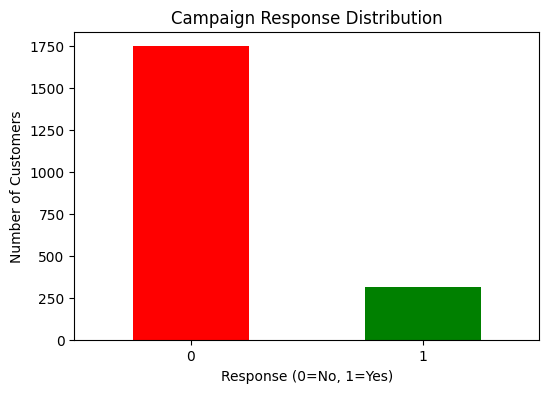

In [22]:
print("Campaign Response Distribution:")
print("-"*30)
print(df['Response'].value_counts())
print(f"\nPercentage who responded: {df['Response'].mean()*100:.1f}%")
print(f"Percentage who did NOT respond: {(1-df['Response'].mean())*100:.1f}%")

# Visualize
plt.figure(figsize=(6,4))
df['Response'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Campaign Response Distribution')
plt.xlabel('Response (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.savefig("../reports/figures/Campaign_response_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

**Insight:** Only 14.9% of customers responded to the campaign. This is class imbalance.<br>
**Action:** Will need to use techniques like class_weight='balanced' or SMOTE.

## 3. DATA QUALITY CHECK

### 3.1 Missing Values Analysis

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print("Columns with missing values:")
    print(missing)
else:
    print("No missing values found!")

# Check percentage of missing
if len(missing) > 0:
    print(f"\nMissing percentage:")
    print((missing/len(df))*100)

Columns with missing values:
Income    24
dtype: int64

Missing percentage:
Income    1.071429
dtype: float64


### Handling Missing Values

In [7]:
df['Income'] = df['Income'].fillna(df['Income'].median())

# Double check no missing values remain
print(f"\nTotal missing values now: {df.isnull().sum().sum()}")


Total missing values now: 0


**Insight:** Only 'Income' column has missing values (24 rows, 1.07%).<br>
**Action:** Filled with median income to avoid data loss.

## 4. FEATURE SELECTION

### 4.1 Removing Non-Informative Columns

In [8]:
print("ALL COLUMNS IN DATASET:")
for col in df.columns:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"{'='*40}")
    print(f"Type: {df[col].dtype}")
    print(f"Unique values: {df[col].nunique()}")
    print(f"Sample values: {df[col].head(3).tolist()}")
    
    # For numeric columns - stats
    if df[col].dtype in ['int64', 'float64']:
        print(f"Min: {df[col].min()}")
        print(f"Max: {df[col].max()}")
        print(f"Mean: {df[col].mean():.2f}")
        

ALL COLUMNS IN DATASET:

Column: ID
Type: int64
Unique values: 2240
Sample values: [5524, 2174, 4141]
Min: 0
Max: 11191
Mean: 5592.16

Column: Year_Birth
Type: int64
Unique values: 59
Sample values: [1957, 1954, 1965]
Min: 1893
Max: 1996
Mean: 1968.81

Column: Education
Type: object
Unique values: 5
Sample values: ['Graduation', 'Graduation', 'Graduation']

Column: Marital_Status
Type: object
Unique values: 8
Sample values: ['Single', 'Single', 'Together']

Column: Income
Type: float64
Unique values: 1975
Sample values: [58138.0, 46344.0, 71613.0]
Min: 1730.0
Max: 666666.0
Mean: 52237.98

Column: Kidhome
Type: int64
Unique values: 3
Sample values: [0, 1, 0]
Min: 0
Max: 2
Mean: 0.44

Column: Teenhome
Type: int64
Unique values: 3
Sample values: [0, 1, 0]
Min: 0
Max: 2
Mean: 0.51

Column: Dt_Customer
Type: object
Unique values: 663
Sample values: ['04-09-2012', '08-03-2014', '21-08-2013']

Column: Recency
Type: int64
Unique values: 100
Sample values: [58, 38, 26]
Min: 0
Max: 99
Mean: 49.1

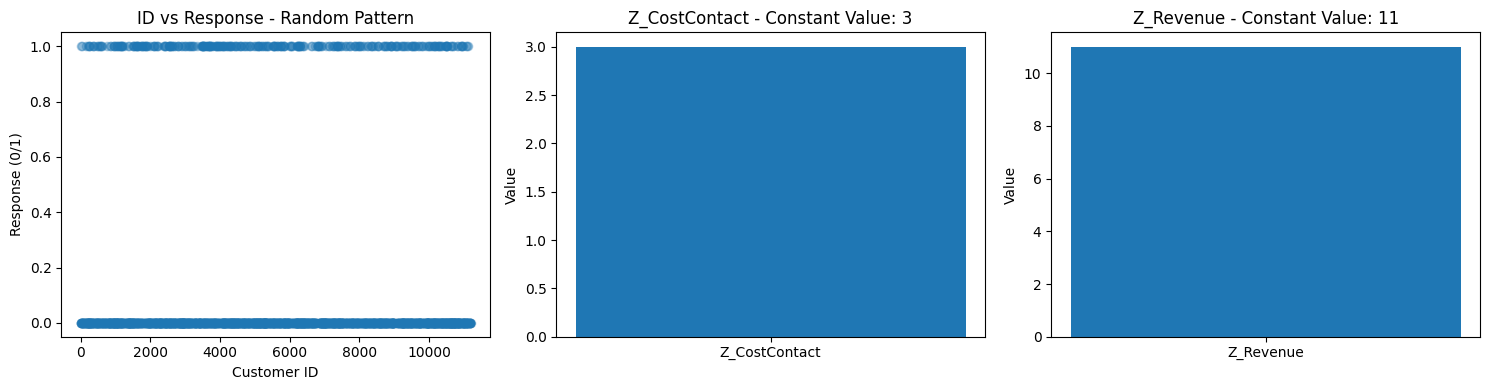

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ID vs Response (random scatter)
axes[0].scatter(df['ID'], df['Response'], alpha=0.3)
axes[0].set_xlabel('Customer ID')
axes[0].set_ylabel('Response (0/1)')
axes[0].set_title('ID vs Response - Random Pattern')

# Z_CostContact (constant)
axes[1].bar(['Z_CostContact'], [df['Z_CostContact'].iloc[0]])
axes[1].set_title(f'Z_CostContact - Constant Value: {df["Z_CostContact"].iloc[0]}')
axes[1].set_ylabel('Value')

# Z_Revenue (constant)
axes[2].bar(['Z_Revenue'], [df['Z_Revenue'].iloc[0]])
axes[2].set_title(f'Z_Revenue - Constant Value: {df["Z_Revenue"].iloc[0]}')
axes[2].set_ylabel('Value')

plt.tight_layout()
plt.savefig('../reports/figures/response_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



Visualization confirms: ID shows random pattern, Z_Revenue, Z_CostContact columns are constant.

In [10]:
# NOW you can drop, with clear documentation
columns_to_drop = ['ID', 'Z_CostContact', 'Z_Revenue']
df = df.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped columns: ['ID', 'Z_CostContact', 'Z_Revenue']
Remaining columns: 26


## 5. DUPLICATE HANDLING

In [11]:
# Find duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Removed duplicates")
else:
    print("No duplicates found")

Duplicate rows: 182
Removed duplicates


## 6. Basic Statistics

In [12]:
# See numerical columns summary
print("Basic Statistics for Numerical Columns:")
print("-"*40)
print(df.describe().round(2))

# Check for weird values
print("\nChecking for unusual values:")
print(f"Minimum age: {df['Year_Birth'].min()}")
print(f"Maximum income: ${df['Income'].max():,.0f}")

Basic Statistics for Numerical Columns:
----------------------------------------
       Year_Birth     Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
count     2058.00    2058.00  2058.00   2058.00  2058.00   2058.00    2058.00   
mean      1968.79   52346.41     0.45      0.51    48.95    303.92      26.23   
std         11.97   25377.82     0.54      0.55    29.00    336.53      39.75   
min       1893.00    1730.00     0.00      0.00     0.00      0.00       0.00   
25%       1959.00   35701.75     0.00      0.00    24.00     23.00       1.00   
50%       1970.00   51381.50     0.00      0.00    49.00    174.00       8.00   
75%       1977.00   68242.50     1.00      1.00    74.00    504.00      33.00   
max       1996.00  666666.00     2.00      2.00    99.00   1493.00     199.00   

       MntMeatProducts  MntFishProducts  MntSweetProducts  ...  \
count           2058.0          2058.00           2058.00  ...   
mean             167.7            37.33             27.18

## 7. OUTLIER ANALYSIS

### 7.1 Age Outliers

In [13]:
# Calculate age from birth year
current_year = 2026
df['Age'] = current_year - df['Year_Birth']

print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")

# Remove unrealistic ages (<18 or >100)
unrealistic_age = (df['Age'] < 18) | (df['Age'] > 100)
print(f"Customers with unrealistic age: {unrealistic_age.sum()}")

if unrealistic_age.sum() > 0:
    # Cap age between 18 and 100
    df['Age'] = df['Age'].clip(lower=18, upper=100)
    print(f"Age range after capping: {df['Age'].min()} to {df['Age'].max()}")

Age range: 30 to 133
Customers with unrealistic age: 3
Age range after capping: 30 to 100


### 7.2 Income Outliers

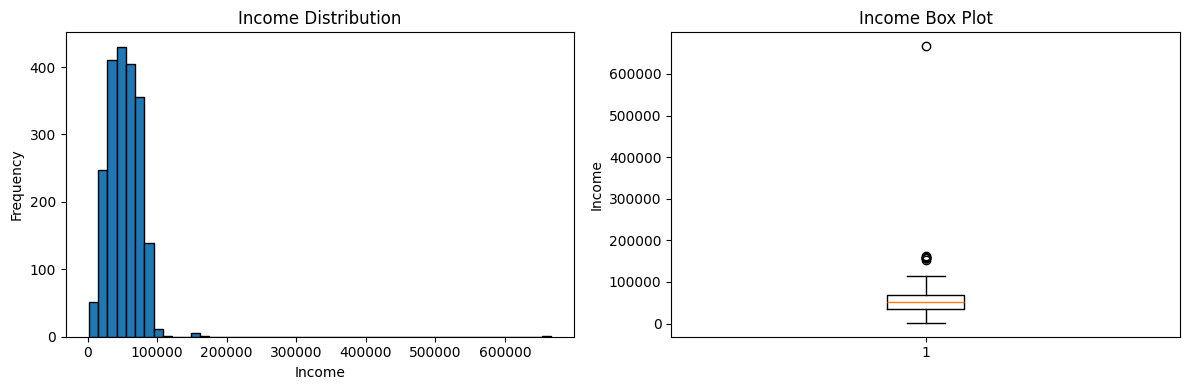

Upper limit (99th percentile): $94,545
Income outliers above $94,545: 21


In [14]:
# Visualize income distribution
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Histogram
axes[0].hist(df['Income'], bins=50, edgecolor='black')
axes[0].set_title('Income Distribution')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['Income'])
axes[1].set_title('Income Box Plot')
axes[1].set_ylabel('Income')

plt.tight_layout()
plt.savefig('../reports/figures/income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# Cap extreme outliers (top 1%)
upper_limit = df['Income'].quantile(0.99)
print(f"Upper limit (99th percentile): ${upper_limit:,.0f}")

outliers = df[df['Income'] > upper_limit]
print(f"Income outliers above ${upper_limit:,.0f}: {len(outliers)}")



In [15]:
df['Income'] = df['Income'].clip(upper=upper_limit)

**Key Findings:**

1. **Skewed Distribution:** Income data is right-skewed (positive skew), indicating a concentration of customers in lower-to-middle income brackets with a long tail of high-income outliers.

2. **Outlier Identification:** The box plot identified extreme outliers above \$150,000, with a maximum of \$666,666. These outliers represent less than 1% of customers but could disproportionately influence model predictions.

3. **Typical Customer Profile:** The majority of customers have incomes between \$20,000 and \$60,000, with a median income of approximately \$51,000.

4. **Data Processing Decision:** Income values were capped at the 99th percentile (\$94,545) to reduce the impact of extreme outliers while preserving the "high-income" customer segment for clustering.

**Business Insight:** The company's customer base is predominantly middle-to-upper-middle class. Campaigns should be designed with price points and messaging appropriate for this income range, while offering premium options for the smaller high-income segment.

## 8. Processing Columns

In [16]:
# 1. Process Date Column
# Convert Dt_Customer to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Customer_Year'] = df['Dt_Customer'].dt.year
df['Customer_Month'] = df['Dt_Customer'].dt.month
df['Customer_Day'] = df['Dt_Customer'].dt.day
df['Days_As_Customer'] = (pd.Timestamp('2026-05-18') - df['Dt_Customer']).dt.days

print(f"Processed date column. Customer tenure range: {df['Days_As_Customer'].min()} to {df['Days_As_Customer'].max()} days")


# 2. Clean Marital Status
print("Original values:")
print(df['Marital_Status'].value_counts())

# Map unusual values to standard categories
marital_map = {
    'Married': 'Married',
    'Together': 'Partnered',
    'Single': 'Single',
    'Divorced': 'Divorced',
    'Widow': 'Widowed',
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
}
df['Marital_Status_Clean'] = df['Marital_Status'].map(marital_map)
print("\nCleaned values:")
print(df['Marital_Status_Clean'].value_counts())



# 3. Create Education Levels (Ordinal)
print("Original education values:")
print(df['Education'].value_counts())

# Create ordinal encoding (higher number = higher education)
education_order = {
    'Basic': 1,
    '2n Cycle': 2,
    'Graduation': 3,
    'Master': 4,
    'PhD': 5
}
df['Education_Level'] = df['Education'].map(education_order)
print(f"Education encoded. Range: {df['Education_Level'].min()} to {df['Education_Level'].max()}")

Processed date column. Customer tenure range: 4341 to 5040 days
Original values:
Marital_Status
Married     795
Together    521
Single      448
Divorced    216
Widow        71
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Cleaned values:
Marital_Status_Clean
Married      795
Partnered    521
Single       455
Divorced     216
Widowed       71
Name: count, dtype: int64
Original education values:
Education
Graduation    1030
PhD            450
Master         341
2n Cycle       188
Basic           49
Name: count, dtype: int64
Education encoded. Range: 1 to 5


## 9. Saving additional figures

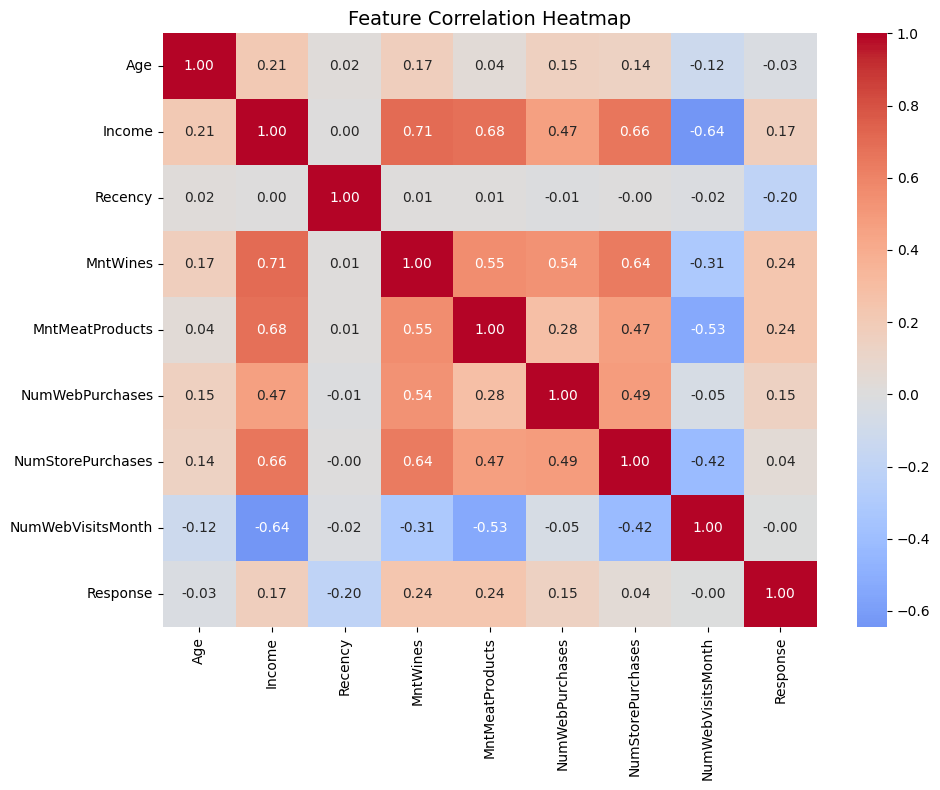

In [23]:
# 1. Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30, edgecolor='black', color='lightgreen')
plt.title('Customer Age Distribution', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/age_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

# 2. Age by Response
plt.figure(figsize=(10,6))
plt.hist(df[df['Response']==1]['Age'], bins=30, alpha=0.6, label='Responded (Yes)', color='green')
plt.hist(df[df['Response']==0]['Age'], bins=30, alpha=0.6, label='Did Not Respond (No)', color='red')
plt.title('Age Distribution by Campaign Response', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/age_by_response.png', dpi=150, bbox_inches='tight')
plt.close()


# 3. Correlation Heatmap
numeric_cols = ['Age', 'Income', 'Recency', 'MntWines', 'MntMeatProducts', 
                'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Response']
available_cols = [col for col in numeric_cols if col in df.columns]

plt.figure(figsize=(10, 8))
corr_matrix = df[available_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


# 4. Marital Status Distribution
plt.figure(figsize=(8,5))
df['Marital_Status_Clean'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Customer Marital Status Distribution', fontsize=14)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/marital_status_distribution.png', dpi=150, bbox_inches='tight')
plt.close()


# 5. Education Level Distribution
plt.figure(figsize=(8,5))
df['Education'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Customer Education Distribution', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/education_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

**Insight:** - 
- Customers with higher income tend to spend more, making them valuable targets.
- Customers who buy premium products like wine and meat usually spend more overall.
- . High-spending and frequent customers are more likely to respond to marketing campaigns.
- Customers who haven’t purchased recently are less likely to respond to campaigns.


**The heatmap helped identify key behavioral relationships, especially between income, spending patterns, and campaign response.**

In [20]:
# Final cleaned data
df.to_csv('../data/processed/cleaned_customers.csv', index=False)


# Target distribution (shows class imbalance)
target_dist = df['Response'].value_counts().to_frame()
target_dist['Percentage'] = (target_dist['count'] / len(df)) * 100
target_dist.to_csv('../reports/tables/target_distribution.csv')


# Key statistics (use for report)
summary_stats = df.describe().round(2)
summary_stats.to_csv('../reports/tables/summary_statistics.csv')
